# Satellite Image Classification using CNN vs Vision Transformer 
### 3504474_ITNPAI1

In [1]:
from google.colab import drive   # **ignore** code to mount dataset to google drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!cp -r /content/drive/MyDrive/Eurosat_dataset /content/   # Uploading dataset into google collab

In [4]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import timm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report


# Defining image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # resize for models
    transforms.ToTensor()            # convert image to tensor
])

# Load dataset
dataset = datasets.ImageFolder(
    #dataset from: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset/code
    root="/content/Eurosat_dataset/",
    transform=transform
)

# basic info
print("Total images:", len(dataset))
print("Classes:", dataset.classes)
print("Number of classes:", len(dataset.classes))

Total images: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Number of classes: 10


In [5]:
from torch.utils.data import random_split

# Split dataset
train_size = int(0.7 * len(dataset))  #75% training data
val_size = int(0.15 * len(dataset))   #15% validation data
test_size = len(dataset) - train_size - val_size    #15% test data

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))


# Create DataLoaders
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

Train size: 18900
Validation size: 4050
Test size: 4050


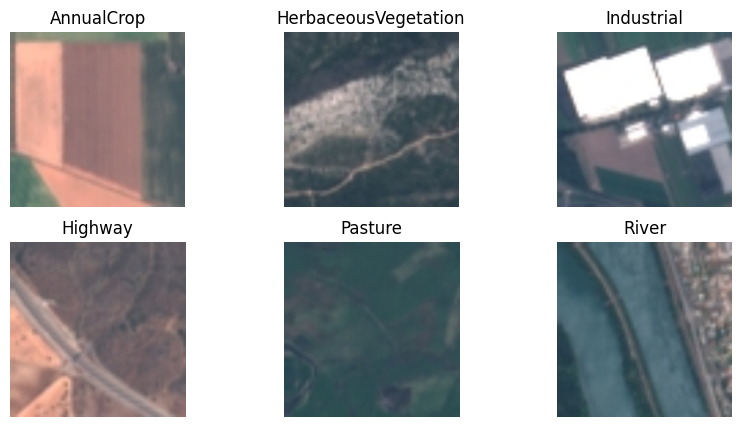

In [ ]:
import matplotlib.pyplot as plt

#visualise sample images
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title(dataset.classes[labels[i].item()])
    plt.axis("off")

## 1. Resnet50 model

In [6]:
import torchvision.models as models
import torch.nn as nn

# Load pretrained ResNet50
model = models.resnet50(pretrained=True)

# Modify final layer for 10 classes
model.fc = nn.Linear(model.fc.in_features, 10)

# Move to device (using GPU / CPU if available)
device = torch.device( "cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Using device:", device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 183MB/s]


Using device: cuda


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [10]:
epochs = 10

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

Epoch [1/10] - Train Loss: 0.2452, Val Loss: 0.0768
Epoch [2/10] - Train Loss: 0.1009, Val Loss: 0.0865
Epoch [3/10] - Train Loss: 0.0752, Val Loss: 0.0774
Epoch [4/10] - Train Loss: 0.0565, Val Loss: 0.0789
Epoch [5/10] - Train Loss: 0.0395, Val Loss: 0.0669
Epoch [6/10] - Train Loss: 0.0426, Val Loss: 0.0760
Epoch [7/10] - Train Loss: 0.0359, Val Loss: 0.0899
Epoch [8/10] - Train Loss: 0.0279, Val Loss: 0.0834
Epoch [9/10] - Train Loss: 0.0291, Val Loss: 0.1328
Epoch [10/10] - Train Loss: 0.0313, Val Loss: 0.1088


In [11]:
#Test Accuracy
correct = 0
total = 0

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = correct / total

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9639506172839506


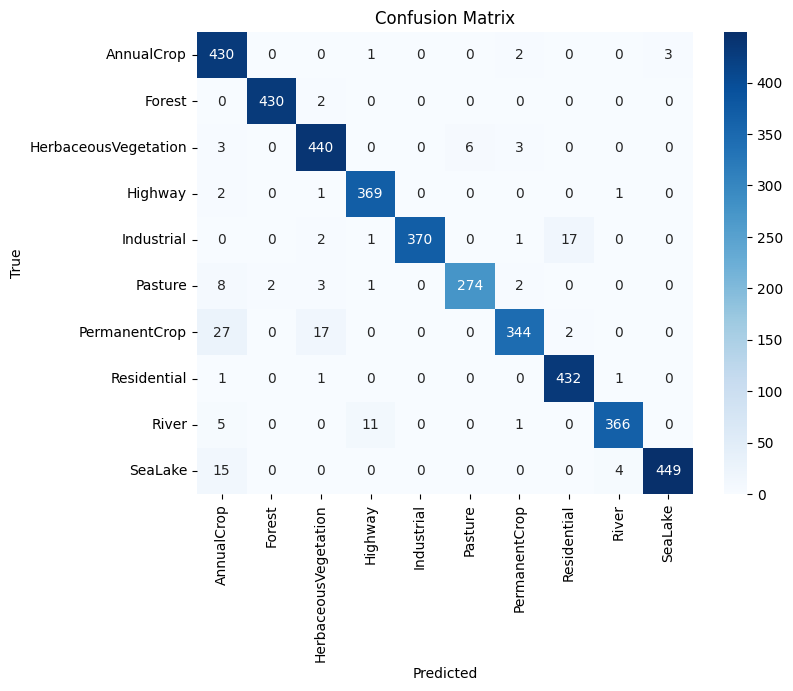

In [12]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dataset.classes,
            yticklabels=dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [13]:
#Classification report
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names=dataset.classes))

                      precision    recall  f1-score   support

          AnnualCrop       0.88      0.99      0.93       436
              Forest       1.00      1.00      1.00       432
HerbaceousVegetation       0.94      0.97      0.96       452
             Highway       0.96      0.99      0.98       373
          Industrial       1.00      0.95      0.97       391
             Pasture       0.98      0.94      0.96       290
       PermanentCrop       0.97      0.88      0.93       390
         Residential       0.96      0.99      0.98       435
               River       0.98      0.96      0.97       383
             SeaLake       0.99      0.96      0.98       468

            accuracy                           0.96      4050
           macro avg       0.97      0.96      0.96      4050
        weighted avg       0.97      0.96      0.96      4050



## 2. Vision Transformer

In [14]:
#Load ViT model
import timm
import torch.nn as nn

model_vit = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=10
)

model_vit = model_vit.to(device)

print("ViT model loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

ViT model loaded


In [15]:
#Loss + optimizer
criterion = nn.CrossEntropyLoss()
optimizer_vit = torch.optim.Adam(model_vit.parameters(), lr=0.0001)

In [16]:
#Training loop
epochs = 10

train_losses_vit = []
val_losses_vit = []

for epoch in range(epochs):
    model_vit.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model_vit(images)
        loss = criterion(outputs, labels)

        optimizer_vit.zero_grad()
        loss.backward()
        optimizer_vit.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses_vit.append(avg_train_loss)

    # Validation
    model_vit.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model_vit(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses_vit.append(avg_val_loss)

    print(f"[ViT] Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

[ViT] Epoch [1/10] - Train Loss: 0.2877, Val Loss: 0.1534
[ViT] Epoch [2/10] - Train Loss: 0.1357, Val Loss: 0.1228
[ViT] Epoch [3/10] - Train Loss: 0.0969, Val Loss: 0.2184
[ViT] Epoch [4/10] - Train Loss: 0.0777, Val Loss: 0.1308
[ViT] Epoch [5/10] - Train Loss: 0.0727, Val Loss: 0.1882
[ViT] Epoch [6/10] - Train Loss: 0.0636, Val Loss: 0.1463
[ViT] Epoch [7/10] - Train Loss: 0.0583, Val Loss: 0.1923
[ViT] Epoch [8/10] - Train Loss: 0.0603, Val Loss: 0.1179
[ViT] Epoch [9/10] - Train Loss: 0.0421, Val Loss: 0.1496
[ViT] Epoch [10/10] - Train Loss: 0.0424, Val Loss: 0.1614


In [17]:
#Accuracy
correct = 0
total = 0

all_preds_vit = []
all_labels_vit = []

model_vit.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model_vit(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds_vit.extend(predicted.cpu().numpy())
        all_labels_vit.extend(labels.cpu().numpy())

accuracy_vit = correct / total

print("ViT Test Accuracy:", accuracy_vit)

ViT Test Accuracy: 0.9565432098765432


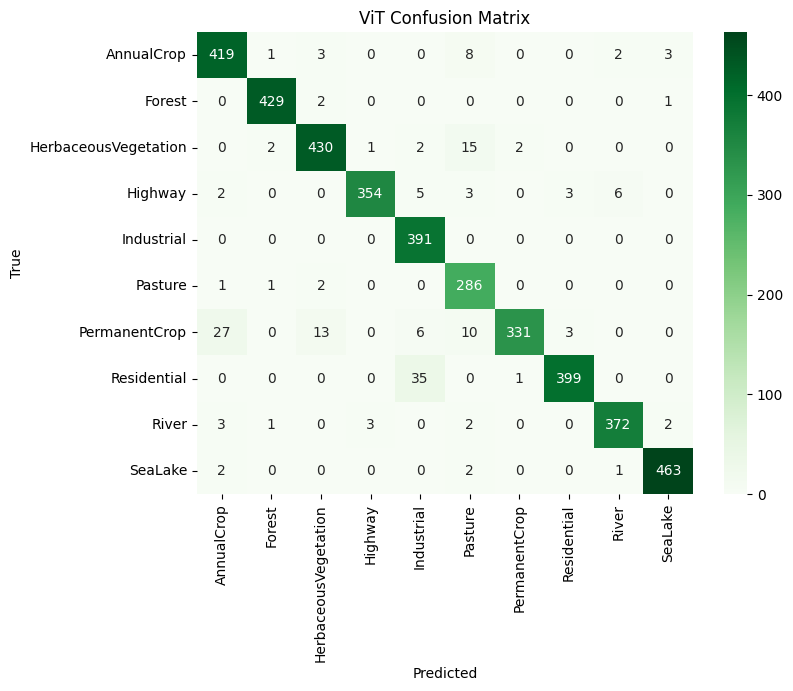

In [18]:
#Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_vit = confusion_matrix(all_labels_vit, all_preds_vit)

plt.figure(figsize=(8,6))
sns.heatmap(cm_vit, annot=True, fmt='d', cmap='Greens',
            xticklabels=dataset.classes,
            yticklabels=dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("ViT Confusion Matrix")
plt.show()

In [19]:
#Classification report
from sklearn.metrics import classification_report

print(classification_report(all_labels_vit, all_preds_vit, target_names=dataset.classes))

                      precision    recall  f1-score   support

          AnnualCrop       0.92      0.96      0.94       436
              Forest       0.99      0.99      0.99       432
HerbaceousVegetation       0.96      0.95      0.95       452
             Highway       0.99      0.95      0.97       373
          Industrial       0.89      1.00      0.94       391
             Pasture       0.88      0.99      0.93       290
       PermanentCrop       0.99      0.85      0.91       390
         Residential       0.99      0.92      0.95       435
               River       0.98      0.97      0.97       383
             SeaLake       0.99      0.99      0.99       468

            accuracy                           0.96      4050
           macro avg       0.96      0.96      0.96      4050
        weighted avg       0.96      0.96      0.96      4050



## ResNet vs ViT Loss Comparison

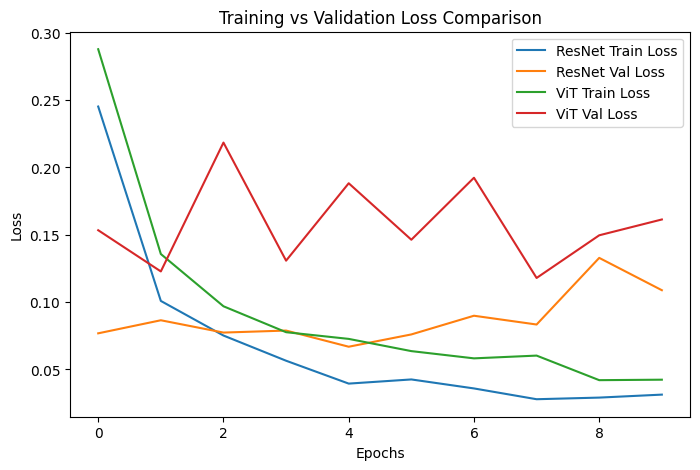

In [20]:
#model Comparison
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="ResNet Train Loss")
plt.plot(val_losses, label="ResNet Val Loss")

plt.plot(train_losses_vit, label="ViT Train Loss")
plt.plot(val_losses_vit, label="ViT Val Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss Comparison")
plt.legend()
plt.show()

In [21]:
#Final accuracy comparison
print("ResNet Accuracy:", accuracy)
print("ViT Accuracy:", accuracy_vit)

ResNet Accuracy: 0.9639506172839506
ViT Accuracy: 0.9565432098765432
